# Fe XES speciation — simple runner

**For everyday use.** Type the run numbers you want, run all cells top to
bottom, and read off the speciation result versus the ferricyanide (Fe³⁺)
reference.

What happens automatically:
1. Each run is processed through the XSpect pipeline **only if it hasn't been
   done before** — previously processed runs are loaded instantly from disk.
2. The runs you list are combined, the minimum is subtracted, and the result
   is area-normalized — separately for Fe Kα and Fe Kβ, within fixed energy
   windows.
3. Your combined spectrum is compared to the ferric reference (IAD + a
   Fe(II)/Fe(III) mixing fraction if a reduced reference is also available).

**You only need to edit the next cell.**

In [1]:
# ============================================================================
#  EDIT THIS CELL ONLY
# ============================================================================

# Which runs to analyse. Examples:
#   RUNS = [9, 10]
#   RUNS = [11, 12, 13]
RUNS = [9, 10]

# Compute resources for any runs that still need processing (ignored for
# runs already done). Leave as-is unless told otherwise.
CORES      = 100
BATCH_SIZE = 500
# ============================================================================

In [2]:
# --- fixed configuration (do not need to change) ----------------------------
import os, sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

HERE     = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT = os.path.abspath(os.path.join(HERE, '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

RESULTS  = os.path.join(HERE, 'results')
os.makedirs(RESULTS, exist_ok=True)
YAML     = os.path.join(HERE, 'mfx102101026_static_xes.yaml')

# Analysis windows (eV)
KA_WIN = (6380.0, 6410.0)
KB_WIN = (7031.0, 7075.0)
N_GRID = 400

# Ferric (Fe³⁺) reference produced by mfx102101026_ferricyanide_reference.ipynb
FERRIC_REF   = os.path.join(RESULTS, 'ferricyanide_ferric_reference.h5')
# Optional reduced (Fe²⁺) reference for LCF mixing fraction (leave as-is if none)
FERROUS_REF  = os.path.join(RESULTS, 'ferrocyanide_ferrous_reference.h5')

# Per-run cache file naming
def cache_path(run):
    return os.path.join(RESULTS, f'run_{run}_static_xes.h5')

print(f'Runs requested: {RUNS}')
print(f'Windows: Kα {KA_WIN} eV, Kβ {KB_WIN} eV')

Runs requested: [9, 10]
Windows: Kα (6380.0, 6410.0) eV, Kβ (7031.0, 7075.0) eV


## 1. Process runs (skips anything already done)

For each requested run, if a cached result already exists it is loaded from
disk. Only runs without a cache are sent through the XSpect pipeline. This
means re-running the notebook with the same runs is instant.

In [3]:
from dataclasses import replace
from XSpect import Pipeline

def process_run(run):
    """Run the XSpect pipeline for a single run and cache the per-run spectra.
    Returns (ka_energy, ka_spec, kb_energy, kb_spec, total_shots)."""
    p = Pipeline.from_yaml(YAML)
    # Override the YAML's run list to just this one run.
    p.config = replace(p.config, data=replace(p.config.data, runs=[run]))
    p.run(cores=CORES, batch_size=BATCH_SIZE)

    ka_e = p.results['kalpha_energy']
    kb_e = p.results['kbeta_energy']
    r = {rr.run_number: rr for rr in p.analyzed_runs}[run]
    ka = np.asarray(r.epix_reduced_ROI_1, dtype=float)
    kb = np.asarray(r.epix_reduced_ROI_2, dtype=float)
    n  = int(getattr(r, 'total_shots', 0))

    # cache to disk so this run is never reprocessed
    with h5py.File(cache_path(run), 'w') as fh:
        fh['kalpha_energy'] = ka_e
        fh['kbeta_energy']  = kb_e
        g = fh.create_group(f'run_{run}')
        g['kalpha'] = ka
        g['kbeta']  = kb
        g.attrs['total_shots'] = n
    return ka_e, ka, kb_e, kb, n

def load_cached(run):
    with h5py.File(cache_path(run), 'r') as fh:
        ka_e = fh['kalpha_energy'][:]
        kb_e = fh['kbeta_energy'][:]
        rk = f'run_{run}' if f'run_{run}' in fh else next(k for k in fh if k.startswith('run_'))
        ka = np.asarray(fh[f'{rk}/kalpha'][:], dtype=float)
        kb = np.asarray(fh[f'{rk}/kbeta'][:], dtype=float)
        n  = int(fh[rk].attrs.get('total_shots', 0))
    return ka_e, ka, kb_e, kb, n

data = {}
for run in RUNS:
    if os.path.exists(cache_path(run)):
        print(f'run {run}: already processed → loading from cache')
        ka_e, ka, kb_e, kb, n = load_cached(run)
    else:
        print(f'run {run}: not cached → processing through XSpect pipeline …')
        ka_e, ka, kb_e, kb, n = process_run(run)
        print(f'run {run}: done and cached')
    data[run] = dict(ka_e=ka_e, ka=ka, kb_e=kb_e, kb=kb, shots=n)

print('\nAll requested runs ready:')
for run in RUNS:
    print(f'  run {run}: {data[run]["shots"]} shots')

run 9: already processed → loading from cache
run 10: already processed → loading from cache

All requested runs ready:
  run 9: 36021 shots
  run 10: 35744 shots


## 2. Combine, subtract minimum, normalize

The requested runs are interpolated onto a common energy grid within each
window and summed. The minimum is subtracted (floor → 0), then the spectrum
is area-normalized. No polynomial baseline fitting.

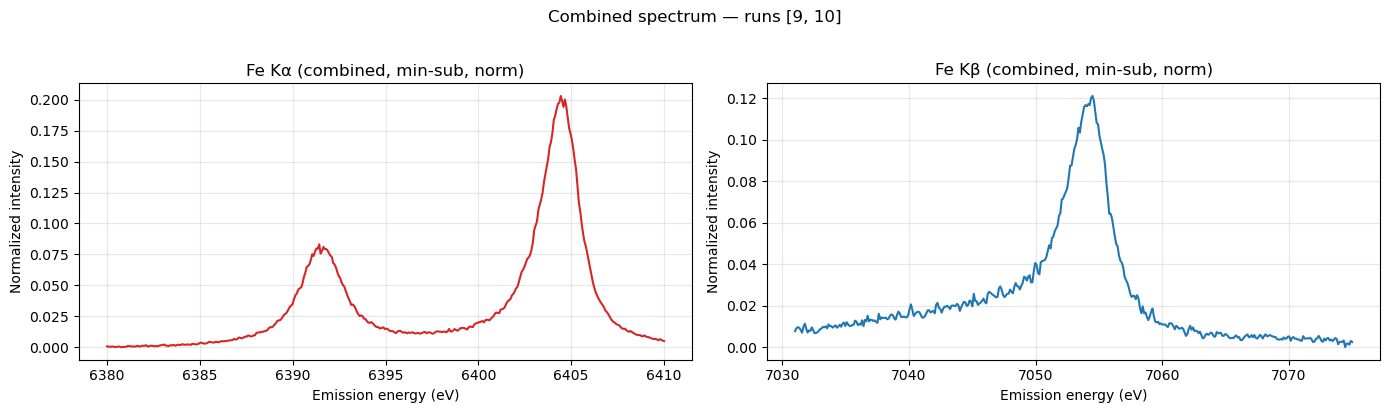

Kα peak @ 6404.44 eV
Kβ peak @ 7054.49 eV


In [4]:
def combine(line, win):
    grid = np.linspace(win[0], win[1], N_GRID)
    total = np.zeros_like(grid)
    for run in RUNS:
        e = data[run][f'{line}_e']; s = data[run][line]
        total += np.interp(grid, e, s, left=0.0, right=0.0)
    return grid, total

def process_spectrum(grid, agg):
    sub = agg - np.nanmin(agg)                 # minimum subtraction
    area = np.trapz(sub, grid)
    norm = sub / area if area > 0 else sub     # area normalization
    return sub, norm

ka_grid, ka_agg = combine('ka', KA_WIN)
kb_grid, kb_agg = combine('kb', KB_WIN)
ka_sub, ka_norm = process_spectrum(ka_grid, ka_agg)
kb_sub, kb_norm = process_spectrum(kb_grid, kb_agg)

fig_combined, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ka_grid, ka_norm, color='C3'); axes[0].set_title('Fe Kα (combined, min-sub, norm)')
axes[1].plot(kb_grid, kb_norm, color='C0'); axes[1].set_title('Fe Kβ (combined, min-sub, norm)')
for ax in axes:
    ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('Normalized intensity'); ax.grid(alpha=0.3)
fig_combined.suptitle(f'Combined spectrum — runs {RUNS}', y=1.02)
fig_combined.tight_layout(); plt.show()

print(f'Kα peak @ {ka_grid[np.argmax(ka_norm)]:.2f} eV')
print(f'Kβ peak @ {kb_grid[np.argmax(kb_norm)]:.2f} eV')

## 3. Speciation vs reference

Compares your combined spectrum to the ferric (Fe³⁺) ferricyanide reference:

- **IAD** (integrated absolute difference) — how far your spectrum is from the
  ferric reference. **IAD ≈ 0 means pure ferric (Fe³⁺).** Larger = more change.
- **Mixing fraction** — if a reduced (Fe²⁺) reference is also present, a
  linear-combination fit reports the estimated Fe(II) fraction.

References are interpolated onto your spectrum's grid so the comparison is
pixel-for-pixel.

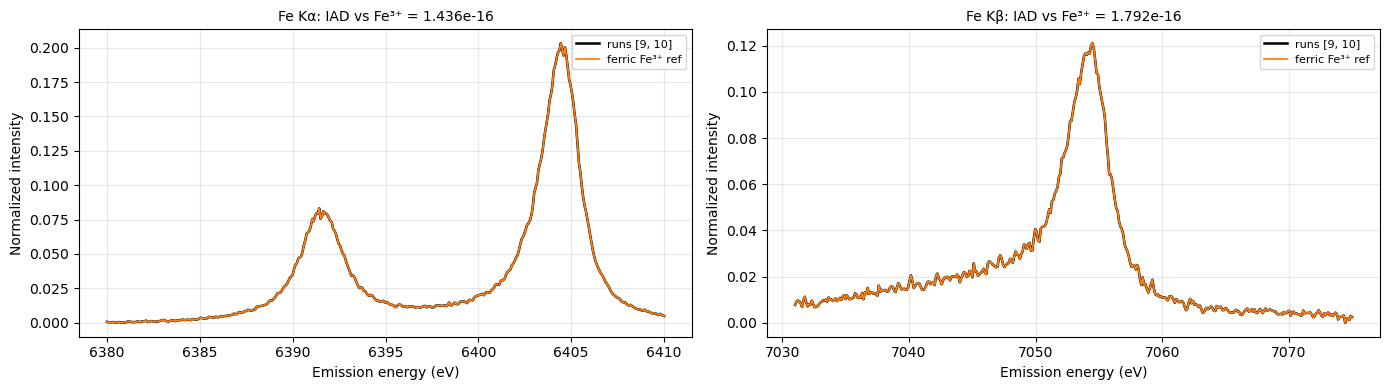

SPECIATION RESULT — runs [9, 10]
  Fe Kα:  IAD vs ferric (Fe³⁺) = 1.4360e-16
  Fe Kβ:  IAD vs ferric (Fe³⁺) = 1.7917e-16

  (No reduced Fe²⁺ reference found — showing IAD only.
   Add one at /sdf/data/lcls/ds/mfx/mfx100895324/results/lbgee/XSpect/experiments/mfx102101026/results/ferrocyanide_ferrous_reference.h5 to get a mixing fraction.)


In [5]:
def load_reference(path):
    """Load a saved reference file. Returns {'kalpha': (e, y), 'kbeta': (e, y)}."""
    out = {}
    with h5py.File(path, 'r') as fh:
        for line in ('kalpha', 'kbeta'):
            e = fh[f'{line}/energy'][:]
            y = fh[f'{line}/normalized'][:]
            out[line] = (e, y)
    return out

def onto(grid, e_ref, y_ref):
    y = np.interp(grid, e_ref, y_ref, left=0.0, right=0.0)
    a = np.trapz(y, grid)
    return y / a if a > 0 else y

def iad(sample, ref, grid):
    return float(np.trapz(np.abs(sample - ref), grid))

def lcf_fraction(sample, ref_ferrous, ref_ferric):
    """Fraction f of ferrous (Fe²⁺): sample ≈ f·ferrous + (1−f)·ferric."""
    basis = ref_ferrous - ref_ferric
    denom = float(np.dot(basis, basis))
    if denom == 0:
        return np.nan
    return float(np.dot(basis, sample - ref_ferric) / denom)

if not os.path.exists(FERRIC_REF):
    print(f'Ferric reference not found at {FERRIC_REF}.')
    print('Generate it with mfx102101026_ferricyanide_reference.ipynb first.')
else:
    ferric = load_reference(FERRIC_REF)
    has_ferrous = os.path.exists(FERROUS_REF)
    ferrous = load_reference(FERROUS_REF) if has_ferrous else None

    fig_speciation, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, line, grid, sample, lbl in [
        (axes[0], 'kalpha', ka_grid, ka_norm, 'Fe Kα'),
        (axes[1], 'kbeta',  kb_grid, kb_norm, 'Fe Kβ'),
    ]:
        ref3 = onto(grid, *ferric[line])
        ax.plot(grid, sample, 'k-', lw=1.8, label=f'runs {RUNS}')
        ax.plot(grid, ref3, color='C1', lw=1.3, label='ferric Fe³⁺ ref')
        val_iad = iad(sample, ref3, grid)
        title = f'{lbl}: IAD vs Fe³⁺ = {val_iad:.3e}'
        if has_ferrous:
            ref2 = onto(grid, *ferrous[line])
            ax.plot(grid, ref2, color='C2', lw=1.3, label='ferrous Fe²⁺ ref')
            f = lcf_fraction(sample, ref2, ref3)
            title += f'  |  Fe²⁺ frac = {100*f:.0f}%'
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('Normalized intensity')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig_speciation.tight_layout(); plt.show()

    print('=' * 60)
    print(f'SPECIATION RESULT — runs {RUNS}')
    print('=' * 60)
    for line, grid, sample, lbl in [
        ('kalpha', ka_grid, ka_norm, 'Fe Kα'),
        ('kbeta',  kb_grid, kb_norm, 'Fe Kβ'),
    ]:
        ref3 = onto(grid, *ferric[line])
        print(f'  {lbl}:  IAD vs ferric (Fe³⁺) = {iad(sample, ref3, grid):.4e}')
        if has_ferrous:
            ref2 = onto(grid, *ferrous[line])
            f = lcf_fraction(sample, ref2, ref3)
            print(f'         estimated Fe²⁺ fraction = {100*f:.1f}%  '
                  f'(Fe³⁺ = {100*(1-f):.1f}%)')
    if not has_ferrous:
        print('\n  (No reduced Fe²⁺ reference found — showing IAD only.')
        print(f'   Add one at {FERROUS_REF} to get a mixing fraction.)')

## 4. Difference spectrum vs ferric reference

Plots **your combined spectrum minus the ferric (Fe³⁺) reference** at each
energy. A flat line near zero means your sample matches pure ferric. Positive
and negative lobes show *where* the spectrum has shifted — the hallmark of a
redox change (e.g. Fe³⁺ → Fe²⁺). The shaded area is the IAD.

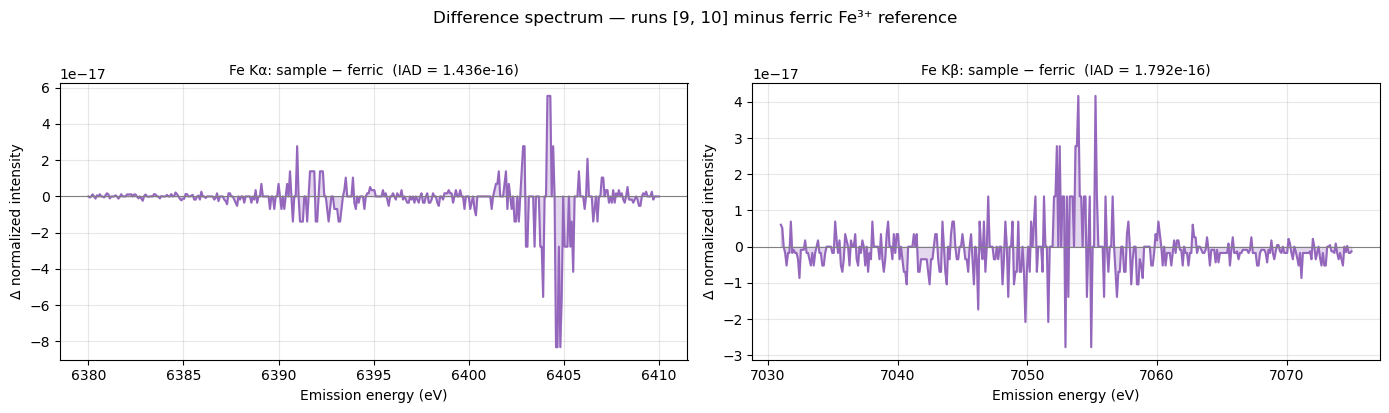

In [6]:
fig_difference = None
if not os.path.exists(FERRIC_REF):
    print('Ferric reference not found — cannot compute a difference spectrum.')
else:
    fig_difference, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, line, grid, sample, lbl in [
        (axes[0], 'kalpha', ka_grid, ka_norm, 'Fe Kα'),
        (axes[1], 'kbeta',  kb_grid, kb_norm, 'Fe Kβ'),
    ]:
        ref3 = onto(grid, *ferric[line])
        diff = sample - ref3
        ax.plot(grid, diff, color='C4', lw=1.5)
        ax.fill_between(grid, diff, 0, color='C4', alpha=0.25)
        ax.axhline(0, color='gray', lw=0.8)
        ax.set_title(f'{lbl}: sample − ferric  (IAD = {iad(sample, ref3, grid):.3e})',
                     fontsize=10)
        ax.set_xlabel('Emission energy (eV)')
        ax.set_ylabel('Δ normalized intensity')
        ax.grid(alpha=0.3)
    fig_difference.suptitle(f'Difference spectrum — runs {RUNS} minus ferric Fe³⁺ reference', y=1.02)
    fig_difference.tight_layout(); plt.show()

## 5. Post beamline summary to the eLog

Compiles the figures generated above into a single HTML page and writes it to
the experiment's eLog **Summaries** tab, so anyone on shift can view the result
without opening this notebook.

The page is labeled by the runs analysed (`RUNS`) and includes:
1. Combined, min-subtracted, normalized Kα/Kβ spectra
2. Speciation vs the ferric (Fe³⁺) reference (with IAD / Fe²⁺ fraction)
3. Difference spectrum vs the ferric reference

The report appears under **Summaries → XSpect_speciation** in the web eLog
(written to `/sdf/data/lcls/ds/mfx/mfx102101026/stats/summary/XSpect_speciation/`).
No credentials needed — it just writes an HTML file the eLog picks up.

In [7]:
# summary_post.py lives in results/lbgee/ (three levels up from this notebook).
import sys
LBGEE_DIR = os.path.abspath(os.path.join(HERE, '..', '..', '..'))
if LBGEE_DIR not in sys.path:
    sys.path.insert(0, LBGEE_DIR)
from summary_post import SummaryPost

# The summary is written under the CURRENT experiment (mfx102101026).
post = SummaryPost('mfx102101026', category='XSpect_speciation')

run_tag = '_'.join(str(r) for r in RUNS)

# Collect the figures produced above, labeled by run set.
figures, titles = [], []
figures.append(fig_combined)
titles.append(f'Runs {RUNS}: combined, min-subtracted, normalized Kα/Kβ')
if 'fig_speciation' in dir() and fig_speciation is not None:
    figures.append(fig_speciation)
    titles.append(f'Runs {RUNS}: speciation vs ferric Fe³⁺ reference')
if 'fig_difference' in dir() and fig_difference is not None:
    figures.append(fig_difference)
    titles.append(f'Runs {RUNS}: difference vs ferric Fe³⁺ reference')

# IAD summary line for the comment header.
comment = f'XSpect Fe Kα/Kβ speciation for runs {RUNS}. '
if os.path.exists(FERRIC_REF):
    parts = []
    for line, grid, sample in [('kalpha', ka_grid, ka_norm), ('kbeta', kb_grid, kb_norm)]:
        ref3 = onto(grid, *ferric[line])
        parts.append(f'{line}: IAD={iad(sample, ref3, grid):.3e}')
    comment += 'vs ferric reference — ' + '; '.join(parts) + '.'

report_path = post.save(
    figures,
    name=f'runs_{run_tag}',
    titles=titles,
    comment=comment,
)
print(f'Beamline summary written for runs {RUNS}:')
print(f'  {report_path}')
print('View it under the eLog "Summaries" tab → XSpect_speciation.')

Summary posted: /sdf/data/lcls/ds/mfx/mfx102101026/stats/summary/XSpect_speciation/runs_9_10/report.html
Beamline summary written for runs [9, 10]:
  /sdf/data/lcls/ds/mfx/mfx102101026/stats/summary/XSpect_speciation/runs_9_10/report.html
View it under the eLog "Summaries" tab → XSpect_speciation.
